In [ ]:
# ============================================================================
# CELL 1: Environment Setup and Version Check
# ============================================================================
import torch
import sys

# Print Python version to verify compatibility
print(sys.version)
# Print PyTorch version and check for CUDA support
print(torch.__version__)

3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
2.8.0+cu126


In [ ]:
# ============================================================================
# CELL 2: Basic PyTorch Autograd Example
# ============================================================================
# Define tensor dimensions: N samples, D features
N, D = 3, 4

# Create random tensors with gradient tracking enabled
# requires_grad=True tells PyTorch to track operations for backpropagation
x = torch.rand((N, D), requires_grad=True)
y = torch.rand((N, D), requires_grad=True)
z = torch.rand((N, D), requires_grad=True)

# Forward pass: define computational graph
a = x * y              # Element-wise multiplication
b = a + z              # Element-wise addition
c = torch.sum(b)       # Reduce to scalar by summing all elements

# Backward pass: compute gradients
c.backward()           # Computes dc/dx, dc/dy, dc/dz

# Display results
print(c.data)          # Final scalar value
print(x.data)          # Original x values
print(x.grad)          # Gradient of c with respect to x (dc/dx)

tensor(8.0171)
tensor([[0.6216, 0.5761, 0.4568, 0.3728],
        [0.2022, 0.5759, 0.3815, 0.0794],
        [0.6703, 0.9256, 0.3012, 0.7459]])
tensor([[0.0692, 0.3008, 0.7972, 0.3270],
        [0.6690, 0.1681, 0.4026, 0.6987],
        [0.7512, 0.5650, 0.3469, 0.7154]])


In [ ]:
# ============================================================================
# CELL 3: Manual Gradient Descent Step
# ============================================================================
# Perform one step of gradient descent with learning rate 0.1
x = x - 0.1 * x.grad   # Update rule: x_new = x_old - lr * gradient

# Recompute forward pass with updated x
a = x * y
b = a + z
c = torch.sum(b)

print(c.data)          # Should be smaller than before (gradient descent)

tensor(7.6692)


In [ ]:
# ============================================================================
# CELL 4: Load FashionMNIST Dataset
# ============================================================================
import torchvision
import torchvision.transforms as transforms

# Define preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),              # Convert PIL Image to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] range
])

# Download and load training data
# root: where to save the data
# train: whether to use training split
# download: download if not already present
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test data
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 342kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.25MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


In [ ]:
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Total samples: {len(train_dataset) + len(test_dataset)}")

# Class names for FashionMNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get a sample image and label
sample_image, sample_label = train_dataset[0]

print(f"\nExample data shape: {sample_image.shape}")
print(f"Example label: {sample_label} ({class_names[sample_label]})")
print(f"Pixel value range: [{sample_image.min():.2f}, {sample_image.max():.2f}]")

Training set size: 60000
Test set size: 10000
Total samples: 70000

Example data shape: torch.Size([1, 28, 28])
Example label: 9 (Ankle boot)
Pixel value range: [-1.00, 1.00]


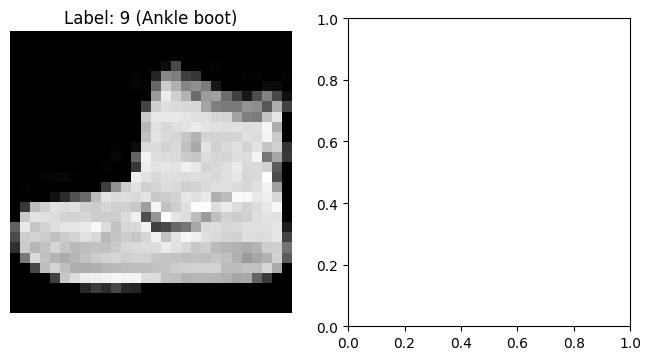

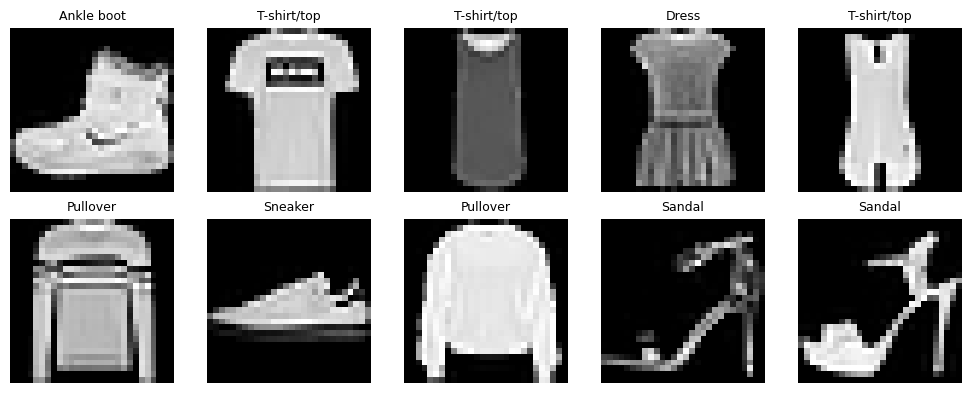

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# Show normalized image
plt.subplot(1, 2, 1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f'Label: {sample_label} ({class_names[sample_label]})')
plt.axis('off')

# Show multiple examples
plt.subplot(1, 2, 2)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 7: Build MLP Model and Training Setup
# ============================================================================

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Create data loaders for batching
# batch_size: number of samples per batch
# shuffle: randomize order for training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define Multi-Layer Perceptron architecture
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Flatten 28x28 images to 784-dimensional vectors
        self.flatten = nn.Flatten()
        # Hidden layers with ReLU activations
        self.fc1 = nn.Linear(28 * 28, 512)  # Input to hidden (784→512)
        self.fc2 = nn.Linear(512, 256)       # Hidden to hidden (512→256)
        self.fc3 = nn.Linear(256, 10)        # Hidden to output (256→10 classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)      # [batch, 1, 28, 28] → [batch, 784]
        x = self.relu(self.fc1(x))  # First hidden layer
        x = self.relu(self.fc2(x))  # Second hidden layer
        x = self.fc3(x)          # Output logits (no activation)
        return x

# Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()  # Combines softmax + negative log likelihood
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Training function for one epoch
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()  # Set model to training mode (enables dropout, etc.)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # Move data to device (GPU if available)
        images, labels = images.to(device), labels.to(device)

        # Zero gradients from previous iteration
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()          # Compute gradients
        optimizer.step()         # Update weights

        # Track metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)  # Get class predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate epoch statistics
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# ============================================================================
# CELL 8: Training Loop
# ============================================================================
num_epochs = 20
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print(f"Training on {device}")
print("-" * 70)

for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    # Evaluate on test set
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Training on cpu
----------------------------------------------------------------------
Epoch [1/20] | Train Loss: 0.4814 | Train Acc: 82.34% | Test Loss: 0.4007 | Test Acc: 85.39%
Epoch [2/20] | Train Loss: 0.3627 | Train Acc: 86.64% | Test Loss: 0.3687 | Test Acc: 86.51%
Epoch [3/20] | Train Loss: 0.3263 | Train Acc: 87.99% | Test Loss: 0.3704 | Test Acc: 86.36%
Epoch [4/20] | Train Loss: 0.3016 | Train Acc: 88.80% | Test Loss: 0.3582 | Test Acc: 87.12%
Epoch [5/20] | Train Loss: 0.2788 | Train Acc: 89.63% | Test Loss: 0.3477 | Test Acc: 87.49%
Epoch [6/20] | Train Loss: 0.2636 | Train Acc: 90.06% | Test Loss: 0.3429 | Test Acc: 87.95%
Epoch [7/20] | Train Loss: 0.2481 | Train Acc: 90.67% | Test Loss: 0.3558 | Test Acc: 87.57%
Epoch [8/20] | Train Loss: 0.2356 | Train Acc: 91.07% | Test Loss: 0.3365 | Test Acc: 88.69%
Epoch [9/20] | Train Loss: 0.2204 | Train Acc: 91.67% | Test Loss: 0.3417 | Test Acc: 88.36%
Epoch [10/20] | Train Loss: 0.2107 | Train Acc: 92.01% | Test Loss: 0.3388 |

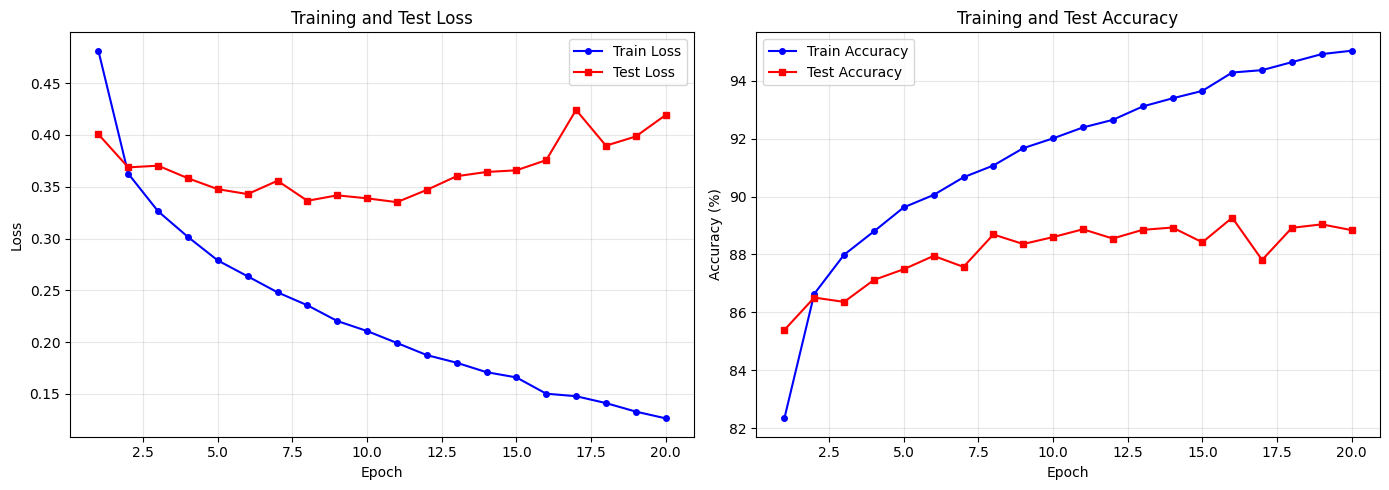

In [ ]:
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot losses
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(range(1, num_epochs + 1), test_losses, 'r-s', label='Test Loss', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracies
ax2.plot(range(1, num_epochs + 1), train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(range(1, num_epochs + 1), test_accs, 'r-s', label='Test Accuracy', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()